# Comparative Evaluation of LLMs for Software Requirement Quality Assurance
**Course:** Adv Software Engineering | **Instructor:** Dr. Justin Kim

**Student:** Akemi Taira Vasuez

---
This notebook evaluates **GPT-4** and **Claude** across two prompting strategies (basic vs. few-shot) for detecting quality issues in software requirements based on ISO 29148 characteristics.

 — Install Dependencies

In [17]:
!pip install openai anthropic scikit-learn openpyxl --quiet

- Set Up API Keys
 Add two secrets:
   - `OPENAI_API_KEY` → your OpenAI key
   - `ANTHROPIC_API_KEY` → your Anthropic key


In [18]:
from google.colab import userdata
import openai
import anthropic

OPENAI_KEY    = userdata.get('OPENAI_API_KEY')
ANTHROPIC_KEY = userdata.get('ANTHROPIC_API_KEY')

openai_client    = openai.OpenAI(api_key=OPENAI_KEY)
anthropic_client = anthropic.Anthropic(api_key=ANTHROPIC_KEY)

print('✅ API clients initialized')

✅ API clients initialized


 Dataset

15 software requirements: mix of flawed and high-quality, functional and non-functional.

ISO 29148 issues tracked: `ambiguity`, `incompleteness`, `lack_of_verifiability`, `inconsistency`


In [19]:
requirements = [
    # ── FLAWED REQUIREMENTS ───────────────────────────────────────────────────
    {
        "id": "REQ-01",
        "text": "The system shall respond quickly.",
        "ground_truth_has_issue": True,
        "ground_truth_issues": ["ambiguity", "lack_of_verifiability"],
        "type": "non-functional"
    },
    {
        "id": "REQ-02",
        "text": "The system should be user-friendly and easy to navigate.",
        "ground_truth_has_issue": True,
        "ground_truth_issues": ["ambiguity", "lack_of_verifiability"],
        "type": "non-functional"
    },
    {
        "id": "REQ-03",
        "text": "The system shall allow users to reset their password.",
        "ground_truth_has_issue": True,
        "ground_truth_issues": ["incompleteness"],
        "type": "functional"
    },
    {
        "id": "REQ-04",
        "text": "The system shall handle errors appropriately.",
        "ground_truth_has_issue": True,
        "ground_truth_issues": ["ambiguity", "incompleteness"],
        "type": "functional"
    },
    {
        "id": "REQ-05",
        "text": "The application must be secure.",
        "ground_truth_has_issue": True,
        "ground_truth_issues": ["ambiguity", "lack_of_verifiability", "incompleteness"],
        "type": "non-functional"
    },
    {
        "id": "REQ-06",
        "text": "The system shall process transactions fast during peak hours.",
        "ground_truth_has_issue": True,
        "ground_truth_issues": ["ambiguity", "lack_of_verifiability"],
        "type": "non-functional"
    },
    {
        "id": "REQ-07",
        "text": "Users should be able to export reports in various formats.",
        "ground_truth_has_issue": True,
        "ground_truth_issues": ["ambiguity", "incompleteness"],
        "type": "functional"
    },
    {
        "id": "REQ-08",
        "text": "The system shall notify users about important events.",
        "ground_truth_has_issue": True,
        "ground_truth_issues": ["ambiguity", "incompleteness"],
        "type": "functional"
    },
    # ── HIGH-QUALITY REQUIREMENTS ─────────────────────────────────────────────
    {
        "id": "REQ-09",
        "text": "The system shall process a login request and return a response within 2 seconds under a load of up to 1,000 concurrent users.",
        "ground_truth_has_issue": False,
        "ground_truth_issues": [],
        "type": "non-functional"
    },
    {
        "id": "REQ-10",
        "text": "The system shall allow registered users to reset their password via a time-limited email link that expires after 15 minutes.",
        "ground_truth_has_issue": False,
        "ground_truth_issues": [],
        "type": "functional"
    },
    {
        "id": "REQ-11",
        "text": "The system shall encrypt all user passwords using bcrypt with a minimum cost factor of 12 before storing them in the database.",
        "ground_truth_has_issue": False,
        "ground_truth_issues": [],
        "type": "non-functional"
    },
    {
        "id": "REQ-12",
        "text": "The system shall allow users to export reports in PDF, CSV, and Excel (.xlsx) formats.",
        "ground_truth_has_issue": False,
        "ground_truth_issues": [],
        "type": "functional"
    },
    {
        "id": "REQ-13",
        "text": "The system shall display an error message reading 'Invalid username or password' when a login attempt fails, without specifying which field is incorrect.",
        "ground_truth_has_issue": False,
        "ground_truth_issues": [],
        "type": "functional"
    },
    {
        "id": "REQ-14",
        "text": "The system shall achieve a System Usability Scale (SUS) score of 80 or above based on user testing with a sample of at least 20 participants.",
        "ground_truth_has_issue": False,
        "ground_truth_issues": [],
        "type": "non-functional"
    },
    {
        "id": "REQ-15",
        "text": "The system shall send an email notification to the user within 60 seconds of a successful or failed payment transaction.",
        "ground_truth_has_issue": False,
        "ground_truth_issues": [],
        "type": "functional"
    },
]

print(f'✅ Dataset loaded: {len(requirements)} requirements')
flawed = sum(1 for r in requirements if r['ground_truth_has_issue'])
print(f'   Flawed: {flawed}  |  High-quality: {len(requirements) - flawed}')

✅ Dataset loaded: 15 requirements
   Flawed: 8  |  High-quality: 7


In [20]:
def get_basic_prompt(requirement_text):
    return f"""You are a software requirements quality analyst.
Evaluate the following software requirement based on ISO 29148 quality characteristics
(ambiguity, incompleteness, lack of verifiability, etc.).

Requirement: "{requirement_text}"

Respond in this exact JSON format:
{{
  "has_issue": true/false,
  "issues_found": ["list of issues or empty list"],
  "explanation": "brief explanation",
  "improved_version": "improved requirement or null if no issues"
}}"""

def get_fewshot_prompt(requirement_text):
    return f"""You are a software requirements quality analyst evaluating requirements per ISO 29148.
Here are three examples covering different types of issues:

Example 1 — AMBIGUITY:
Requirement: "The system shall be user-friendly."
Response: {{"has_issue": true, "issues_found": ["ambiguity", "lack_of_verifiability"], "explanation": "'User-friendly' is subjective with no measurable definition.", "improved_version": "The system shall achieve a System Usability Scale (SUS) score of 80 or above in user testing with at least 20 participants."}}

Example 2 — INCOMPLETENESS:
Requirement: "The system shall allow users to reset their password."
Response: {{"has_issue": true, "issues_found": ["incompleteness"], "explanation": "Missing how the reset works, what method is used, and any time constraints.", "improved_version": "The system shall allow users to reset their password via a time-limited email link that expires after 15 minutes."}}

Example 3 — NO ISSUE (HIGH QUALITY):
Requirement: "The system shall encrypt all passwords using bcrypt with a minimum cost factor of 12."
Response: {{"has_issue": false, "issues_found": [], "explanation": "Requirement is specific, complete, and fully verifiable.", "improved_version": null}}

Now evaluate:
Requirement: "{requirement_text}"
Respond in the same JSON format."""
print('✅ Prompts defined')

✅ Prompts defined


Model Query Functions

In [21]:
import json, time

def query_gpt4(prompt):
    response = openai_client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        temperature=0
    )
    return response.choices[0].message.content


def query_claude(prompt):
    response = anthropic_client.messages.create(
        model="claude-opus-4-6",
        max_tokens=1024,
        messages=[{"role": "user", "content": prompt}]
    )
    return response.content[0].text


def safe_parse(raw):
    """Try to parse JSON from model output, handle fences or stray text."""
    try:
        clean = raw.strip().removeprefix("```json").removeprefix("```").removesuffix("```").strip()
        return json.loads(clean)
    except Exception:
        return {"parse_error": True, "raw": raw}


print('✅ Model functions ready')

✅ Model functions ready


Run the Experiment
> This cell queries all requirements and both prompting strategies (4 conditions total per requirement).

In [22]:
import pandas as pd

models = [
    ("gpt-4o-mini",  query_gpt4),
    ("Claude", query_claude),
]
strategies = [
    ("basic",    get_basic_prompt),
    ("few-shot", get_fewshot_prompt),
]

results = []

for req in requirements:
    for model_name, query_fn in models:
        for strategy_name, prompt_fn in strategies:
            print(f'  Running {req["id"]} | {model_name} | {strategy_name}...', end=' ')
            prompt     = prompt_fn(req["text"])
            raw_output = query_fn(prompt)
            parsed     = safe_parse(raw_output)

            results.append({
                "req_id":            req["id"],
                "req_type":          req["type"],
                "requirement_text":  req["text"],
                "model":             model_name,
                "strategy":          strategy_name,
                "ground_truth":      req["ground_truth_has_issue"],
                "gt_issues":         ", ".join(req["ground_truth_issues"]) or "none",
                "predicted":         parsed.get("has_issue"),
                "issues_found":      ", ".join(parsed.get("issues_found", [])) or "none",
                "explanation":       parsed.get("explanation", ""),
                "improved_version":  parsed.get("improved_version", ""),
                "parse_error":       parsed.get("parse_error", False),
            })
            print('✅')
            time.sleep(0.5)  # gentle rate-limit buffer

df = pd.DataFrame(results)
print(f'\n🎉 Done! {len(df)} total evaluations collected.')
df.head(8)

  Running REQ-01 | gpt-4o-mini | basic... ✅
  Running REQ-01 | gpt-4o-mini | few-shot... ✅
  Running REQ-01 | Claude | basic... ✅
  Running REQ-01 | Claude | few-shot... ✅
  Running REQ-02 | gpt-4o-mini | basic... ✅
  Running REQ-02 | gpt-4o-mini | few-shot... ✅
  Running REQ-02 | Claude | basic... ✅
  Running REQ-02 | Claude | few-shot... ✅
  Running REQ-03 | gpt-4o-mini | basic... ✅
  Running REQ-03 | gpt-4o-mini | few-shot... ✅
  Running REQ-03 | Claude | basic... ✅
  Running REQ-03 | Claude | few-shot... ✅
  Running REQ-04 | gpt-4o-mini | basic... ✅
  Running REQ-04 | gpt-4o-mini | few-shot... ✅
  Running REQ-04 | Claude | basic... ✅
  Running REQ-04 | Claude | few-shot... ✅
  Running REQ-05 | gpt-4o-mini | basic... ✅
  Running REQ-05 | gpt-4o-mini | few-shot... ✅
  Running REQ-05 | Claude | basic... ✅
  Running REQ-05 | Claude | few-shot... ✅
  Running REQ-06 | gpt-4o-mini | basic... ✅
  Running REQ-06 | gpt-4o-mini | few-shot... ✅
  Running REQ-06 | Claude | basic... ✅
  Running 

,req_id,req_type,requirement_text,model,strategy,ground_truth,gt_issues,predicted,issues_found,explanation,improved_version,parse_error
0,REQ-01,non-functional,The system shall respond quickly.,gpt-4o-mini,basic,True,"ambiguity, lack_of_verifiability",True,"ambiguity, lack of verifiability",The requirement 'The system shall respond quic...,The system shall respond to user requests with...,False
1,REQ-01,non-functional,The system shall respond quickly.,gpt-4o-mini,few-shot,True,"ambiguity, lack_of_verifiability",True,"ambiguity, lack_of_verifiability",'Quickly' is a subjective term that lacks a sp...,The system shall respond to user requests with...,False
2,REQ-01,non-functional,The system shall respond quickly.,Claude,basic,True,"ambiguity, lack_of_verifiability",True,Ambiguity: 'quickly' is a subjective and vague...,The term 'quickly' is inherently subjective an...,The system shall respond to user-initiated req...,False
3,REQ-01,non-functional,The system shall respond quickly.,Claude,few-shot,True,"ambiguity, lack_of_verifiability",True,"ambiguity, lack_of_verifiability, incompleteness",'Quickly' is subjective and unmeasurable. The ...,The system shall respond to any user-initiated...,False
4,REQ-02,non-functional,The system should be user-friendly and easy to...,gpt-4o-mini,basic,True,"ambiguity, lack_of_verifiability",True,"ambiguity, lack of verifiability",The terms 'user-friendly' and 'easy to navigat...,The system should allow users to complete a ta...,False
5,REQ-02,non-functional,The system should be user-friendly and easy to...,gpt-4o-mini,few-shot,True,"ambiguity, lack_of_verifiability",True,"ambiguity, lack_of_verifiability",'User-friendly' and 'easy to navigate' are sub...,The system shall achieve a System Usability Sc...,False
6,REQ-02,non-functional,The system should be user-friendly and easy to...,Claude,basic,True,"ambiguity, lack_of_verifiability",True,Ambiguity: 'user-friendly' and 'easy to naviga...,This requirement is a classic example of a non...,The system shall enable users with no prior tr...,False
7,REQ-02,non-functional,The system should be user-friendly and easy to...,Claude,few-shot,True,"ambiguity, lack_of_verifiability",True,"ambiguity, lack_of_verifiability, use_of_weak_...",'User-friendly' and 'easy to navigate' are sub...,The system shall achieve a System Usability Sc...,False


Compute Metrics

In [23]:
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score

summary_rows = []

for (model, strategy), group in df.groupby(["model", "strategy"]):
    valid = group.dropna(subset=["predicted"])
    gt   = valid["ground_truth"].astype(int)
    pred = valid["predicted"].astype(int)

    summary_rows.append({
        "Model":     model,
        "Strategy":  strategy,
        "Accuracy":  round(accuracy_score(gt, pred), 3),
        "Precision": round(precision_score(gt, pred, zero_division=0), 3),
        "Recall":    round(recall_score(gt, pred, zero_division=0), 3),
        "F1 Score":  round(f1_score(gt, pred, zero_division=0), 3),
        "N":         len(valid)
    })

summary_df = pd.DataFrame(summary_rows).sort_values(["Model", "Strategy"])
print("=== Metric Summary ===")
summary_df

=== Metric Summary ===


,Model,Strategy,Accuracy,Precision,Recall,F1 Score,N
0,Claude,basic,0.600,0.571,1.0,0.727,15
1,Claude,few-shot,1.000,1.000,1.0,1.000,15
2,gpt-4o-mini,basic,0.933,0.889,1.0,0.941,15
3,gpt-4o-mini,few-shot,0.933,0.889,1.0,0.941,15


Visualize Results

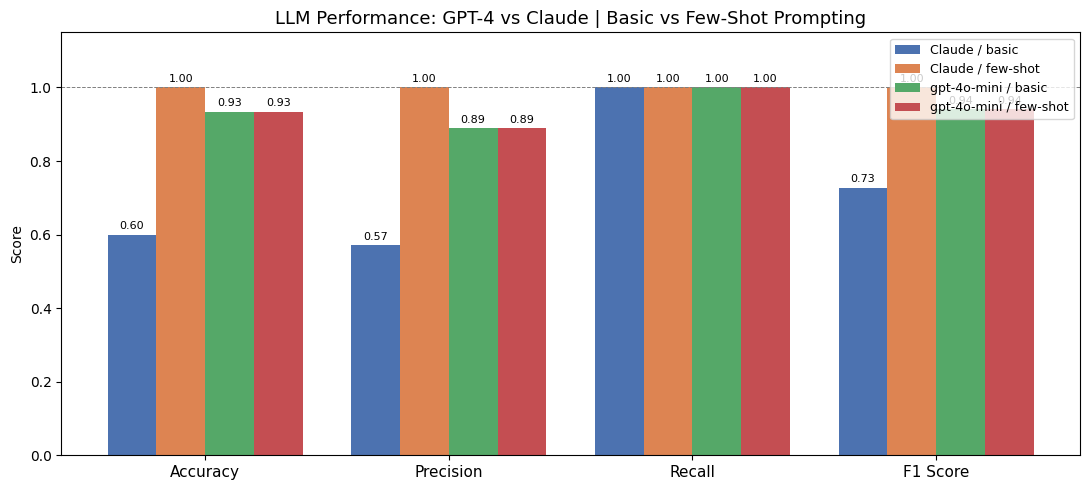

✅ Chart saved as metrics_chart.png


In [24]:
import matplotlib.pyplot as plt
import numpy as np

metrics    = ["Accuracy", "Precision", "Recall", "F1 Score"]
conditions = summary_df["Model"] + " / " + summary_df["Strategy"]
x          = np.arange(len(metrics))
width      = 0.2
colors     = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig, ax = plt.subplots(figsize=(11, 5))

for i, (_, row) in enumerate(summary_df.iterrows()):
    values = [row[m] for m in metrics]
    bars   = ax.bar(x + i * width, values, width, label=conditions.iloc[i], color=colors[i])
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_title("LLM Performance: GPT-4 vs Claude | Basic vs Few-Shot Prompting", fontsize=13)
ax.legend(loc="upper right", fontsize=9)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.7)
plt.tight_layout()
plt.savefig("metrics_chart.png", dpi=150)
plt.show()
print('✅ Chart saved as metrics_chart.png')

Export Results

In [25]:
from google.colab import files

# Full detailed results
df.to_excel("detailed_results.xlsx", index=False)

# Metric summary
summary_df.to_excel("metrics_summary.xlsx", index=False)

# Download all three
files.download('detailed_results.xlsx')
files.download('metrics_summary.xlsx')
files.download('metrics_chart.png')

print('✅ Files downloaded!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Files downloaded!


Qualitative Inspection

Review model explanations and make suggestion for any specific requirement.

In [26]:
# Change REQ_ID to inspect any requirement
REQ_ID = "REQ-01"

subset = df[df["req_id"] == REQ_ID]
print(f'Requirement: {subset.iloc[0]["requirement_text"]}')
print(f'Ground Truth Issues: {subset.iloc[0]["gt_issues"]}\n')
print("-" * 60)

for _, row in subset.iterrows():
    print(f'[{row["model"]} | {row["strategy"]}]')
    print(f'  Predicted Issue : {row["predicted"]}')
    print(f'  Issues Found    : {row["issues_found"]}')
    print(f'  Explanation     : {row["explanation"]}')
    print(f'  Improved Version: {row["improved_version"]}')
    print()

Requirement: The system shall respond quickly.
Ground Truth Issues: ambiguity, lack_of_verifiability

------------------------------------------------------------
[gpt-4o-mini | basic]
  Predicted Issue : True
  Issues Found    : ambiguity, lack of verifiability
  Explanation     : The requirement 'The system shall respond quickly' is ambiguous because it does not specify what 'quickly' means in terms of measurable performance criteria. Additionally, it lacks verifiability since there are no defined metrics or thresholds to assess whether the system meets this requirement.
  Improved Version: The system shall respond to user requests within 2 seconds under normal operating conditions.

[gpt-4o-mini | few-shot]
  Predicted Issue : True
  Issues Found    : ambiguity, lack_of_verifiability
  Explanation     : 'Quickly' is a subjective term that lacks a specific time frame for response, making it difficult to measure performance.
  Improved Version: The system shall respond to user request